In [65]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/tawfikelmetwally/wine-dataset/Wine dataset.csv


In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [67]:
df=pd.read_csv('/kaggle/input/datasets/tawfikelmetwally/wine-dataset/Wine dataset.csv',usecols=[0,1,2])

In [68]:
df.head()

,class,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

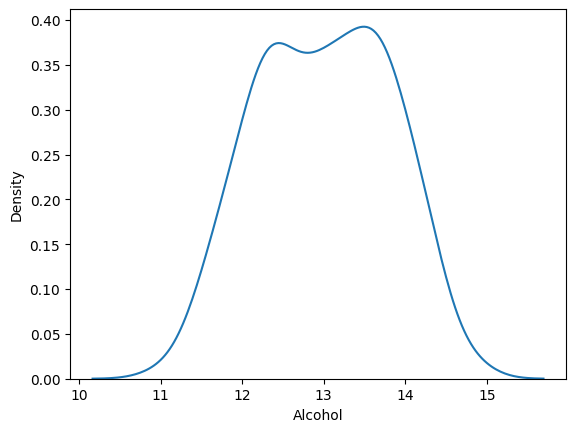

In [69]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

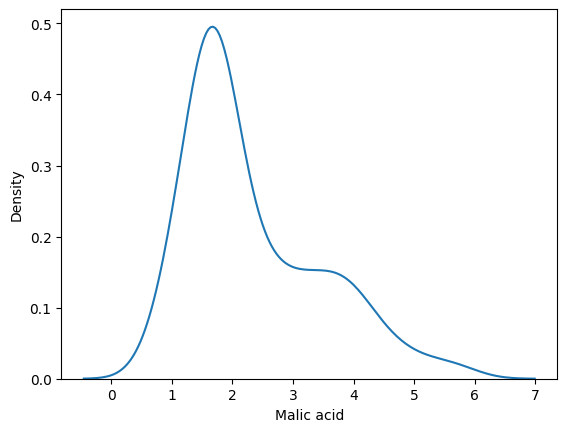

In [70]:
sns.kdeplot(df['Malic acid'])

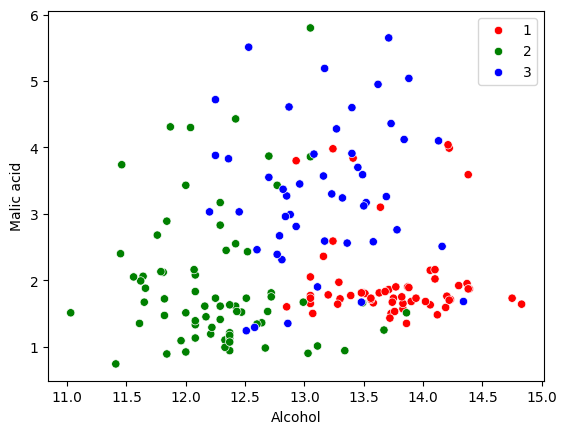

In [71]:
sns.scatterplot(x=df['Alcohol'],y=df['Malic acid'],hue=df['class'],palette=['red','green','blue'])
plt.legend()

In [72]:
# Now lets move to train and test and split data before doing feature scaling

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(df.drop('class',axis=1),
                                              df['class'],
                                              test_size=0.2,
                                              random_state=42)

In [73]:
x_train.shape,x_test.shape

((142, 2), (36, 2))

In [74]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()
scaler.fit(x_train)

x_train_scaled = scaler. transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [75]:
x_train_scaled

array([[0.87105263, 0.16089613],
       [0.39473684, 0.94093686],
       [0.35263158, 0.03665988],
       [0.64473684, 0.15885947],
       [0.53684211, 0.12423625],
       [0.31315789, 0.0814664 ],
       [0.43157895, 0.01832994],
       [0.60789474, 0.0101833 ],
       [0.68157895, 0.82688391],
       [0.56052632, 0.299389  ],
       [0.27631579, 0.24236253],
       [0.36578947, 0.7209776 ],
       [0.40789474, 0.0814664 ],
       [0.73684211, 0.15478615],
       [0.52631579, 0.00203666],
       [0.83947368, 0.16496945],
       [0.62105263, 0.17922607],
       [0.57894737, 0.49083503],
       [0.64736842, 0.54989817],
       [0.38947368, 0.17107943],
       [0.34210526, 0.0203666 ],
       [0.59210526, 0.15274949],
       [0.33157895, 0.39511202],
       [0.70526316, 0.19755601],
       [0.75      , 0.84521385],
       [0.33157895, 0.10590631],
       [0.31052632, 0.0610998 ],
       [0.47105263, 0.50509165],
       [0.81315789, 0.12016293],
       [0.88421053, 0.19959267],
       [0.

In [76]:
x_train_scaled= pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [79]:
x_train_scaled.describe()

,Alcohol,Malic acid
count,142.000000,142.000000
mean,0.512917,0.302143
std,0.215820,0.232980
min,0.000000,0.000000
25%,0.342763,0.147658
50%,0.521053,0.200611
75%,0.696711,0.457230
max,1.000000,1.000000


In [80]:
x_train.describe()

,Alcohol,Malic acid
count,142.000000,142.000000
mean,12.979085,2.373521
std,0.820116,1.143934
min,11.030000,0.890000
25%,12.332500,1.615000
50%,13.010000,1.875000
75%,13.677500,3.135000
max,14.830000,5.800000


Text(0.5, 1.0, 'After Scaling')

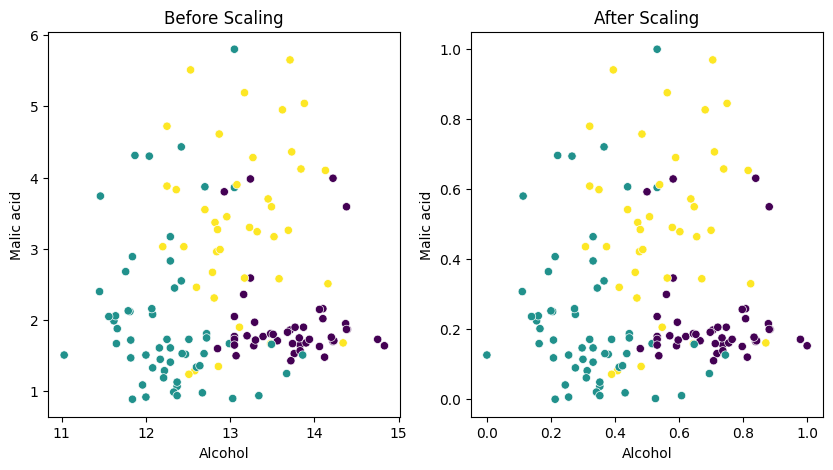

In [90]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.scatterplot(x=x_train['Alcohol'],y=x_train['Malic acid'],c=y_train)
plt.title('Before Scaling')

plt.subplot(1,2,2)
sns.scatterplot(x=x_train_scaled['Alcohol'],y=x_train_scaled['Malic acid'],c=y_train)
plt.title('After Scaling')

/tmp/ipykernel_55/3978558415.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


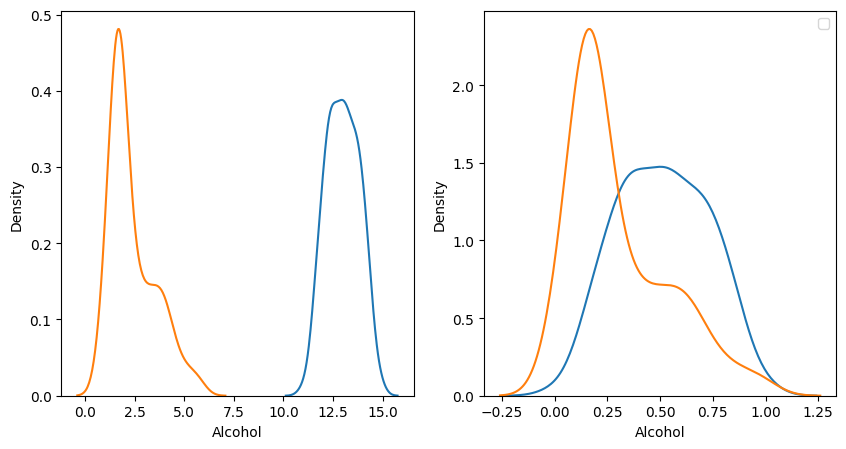

In [95]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.kdeplot(x_train['Alcohol'])
sns.kdeplot(x_train['Malic acid'])

plt.subplot(1,2,2)
sns.kdeplot(x_train_scaled['Alcohol'])
sns.kdeplot(x_train_scaled['Malic acid'])
plt.legend()